# 06 · Tarea 3 — AutoML con Keras Tuner

**Objetivo.** Buscar automáticamente la **topología** de la red de impago con **Keras Tuner** (estrategia **Hyperband** o *RandomSearch*, **D-3.1**) sobre un espacio de hiperparámetros que incluye **nº de capas**, **unidades por capa**, **dropout + su `rate` (sí o sí)**, **learning rate** (escala log), **función de activación** y **`λ_fair`** (**D-3.2**). El `objective` del tuner es **`val_auc`** a maximizar (**D-3.4**), tratando el **fairness como eje externo** y no como objetivo del escalar.

Como el tuner optimiza un único escalar, la frontera de Pareto **no sale gratis**: se construye con un **bucle externo sobre `λ`** (**D-3.3**) que, para cada valor, reentrena/busca la mejor topología y registra el par **(AUC, group gap)** → eso produce el entregable **E2** (Pareto Precisión vs Dependencia FAIR).

El `build_model(hp)` integra la **capa custom** del notebook 04 (ratio + saturación `x^p`) y la **FAIR loss** `BCE + λ·D` del notebook 05; la **mejor topología con dropout** que aquí se fija la **hereda el notebook 07** para **MC-Dropout** (cruce **D-3.2 ↔ D-4.1**). Aguas arriba depende de 03 (baseline de precisión), 04 (capa) y 05 (loss).

## Decisiones a tomar antes de empezar

> Fichas de `docs/DECISIONES.md` para esta tarea. **Estado real** copiado tal cual.
> Las decisiones en **Propuesta**/**Abierta** se **validan con el grupo ANTES de
> implementar**: este notebook asume la *Propuesta* por defecto, pero es revisable.

| Decisión | Opciones | Estado |
|---|---|---|
| **D-3.1** · Estrategia de búsqueda | RandomSearch / **Hyperband** / BayesianOptimization | Propuesta |
| **D-3.2** · Hiperparámetros del espacio | nº capas / unidades / **dropout (+rate)** / lr (log) / activación / λ_fair | Propuesta |
| **D-3.3** · Extraer pares (precisión, dependencia) | callback / **bucle externo sobre λ** / tuner multiobjetivo | Propuesta |
| **D-3.4** · Métrica objetivo del tuner | val_loss / **val_auc** / custom combinada | Propuesta |

> **Cruce dropout 3↔4 (D-3.2 ↔ D-4.1).** El **dropout entra obligatoriamente** en el espacio de búsqueda **porque** el notebook 07 reutiliza esta misma topología para **MC-Dropout** (T pasadas con `training=True` en inferencia → `Var[p]`). Es decir, **07 hereda la red con dropout** que aquí se fija; no introduce un dropout nuevo desacoplado.

> **Fairness como eje externo.** El tuner **NO optimiza fairness**: su `objective` es `val_auc` (D-3.4). El **group gap** (D-2.3, línea base EDA **+3,14 pp**) se recoge en el **bucle externo sobre `λ`** (D-3.3) para trazar la Pareto. **Validar estas decisiones con el grupo antes de codificar.**

## Setup e imports

> **Aviso de instalación.** Este notebook usa **`keras-tuner`**, que **NO está
> instalado por defecto** en el entorno (sí lo están `keras` 3.x y `tensorflow`).
> Antes de lanzar la búsqueda del tuner hay que instalarlo:
>
> ```bash
> pip install keras-tuner --upgrade
> ```
>
> El import va **guardado con `try/except`** para que el esqueleto no se rompa
> aunque la librería falte; las celdas de búsqueda (`# TODO`) solo se ejecutan
> tras instalarla.

In [1]:
# === Setup comun (notebooks de modelado 03-07) ===
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # backend unico para todo el grupo

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RNG = 42
np.random.seed(RNG)
import random; random.seed(RNG)
try:
    import keras
    keras.utils.set_random_seed(RNG)
except Exception:
    pass

# Estilo heredado del EDA / preprocesado
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLOR_PAGA   = "#2c7fb8"   # TARGET=0  (paga)
COLOR_IMPAGA = "#d7301f"   # TARGET=1  (impaga)
COLOR_ACENTO = "#41ab5d"   # neutro

# Rutas estandar
PROC_DIR = Path("../data/processed")
FIG_DIR  = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR  = Path("../results/tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- Especifico de la Tarea 3 (Keras Tuner) ---
import sys; sys.path.append("..")   # para importar src/ (p.ej. src/tuning.py)
import keras

# Import guardado: keras-tuner NO esta instalado por defecto (ver nota previa)
try:
    import keras_tuner as kt
    _HAS_KT = True
except ImportError:
    _HAS_KT = False
    print("keras-tuner no instalado -> pip install keras-tuner --upgrade")

In [2]:
import json
from pathlib import Path
import pandas as pd

# --- Rutas y metadatos (fuente de verdad: metadata.json del preprocesado) ---
PROC_DIR   = Path("../data/processed")                       # relativo a notebooks/
META       = json.loads((PROC_DIR / "metadata.json").read_text(encoding="utf-8"))
FEATURES_X = META["columns"]["features_X"]   # 13 features, en orden
SENSIBLE   = META["columns"]["sensible"]     # "CODE_GENDER"  (s)
TARGET     = META["columns"]["target"]       # "TARGET"       (y)

def cargar_split(nombre):
    """Devuelve (X, y, s) para 'train' | 'val' | 'test'.
    X = DataFrame solo con las 13 features (SIN genero).
    y = Series TARGET (1=impaga, 0=paga).  s = Series CODE_GENDER (M=1/F=0).
    """
    df = pd.read_parquet(PROC_DIR / f"{nombre}.parquet")
    X = df[FEATURES_X]          # input del modelo: el genero NUNCA entra aqui
    y = df[TARGET]
    s = df[SENSIBLE]
    assert SENSIBLE not in X.columns, "FUGA: el genero esta dentro de X"
    return X, y, s

# Materializar los tres cortes
X_train, y_train, s_train = cargar_split("train")
X_val,   y_val,   s_val   = cargar_split("val")
X_test,  y_test,  s_test  = cargar_split("test")

# Nota: convertir a tensores con X_*.to_numpy(dtype="float32") (idem y_*, s_*) en el
# punto de uso; s = CODE_GENDER NUNCA entra en X (solo FAIR loss + auditoria de equidad).

# Resumen de control
print(f"{'split':<7}{'X (filas, cols)':>20}{'y':>12}{'s':>12}{'tasa_impago':>14}")
for n, (X, y, s) in {"train": (X_train, y_train, s_train),
                     "val":   (X_val,   y_val,   s_val),
                     "test":  (X_test,  y_test,  s_test)}.items():
    print(f"{n:<7}{str(tuple(X.shape)):>20}{str(tuple(y.shape)):>12}"
          f"{str(tuple(s.shape)):>12}{y.mean():>14.4%}")

split       X (filas, cols)           y           s   tasa_impago
train          (215254, 13)   (215254,)   (215254,)       8.0728%
val             (46126, 13)    (46126,)    (46126,)       8.0735%
test            (46127, 13)    (46127,)    (46127,)       8.0734%


## Espacio de búsqueda y `build_model(hp)`

Aquí se definirá la función `build_model(hp)` (en `src/tuning.py`) que declara el **espacio de búsqueda** con la API de Keras Tuner (D-3.2): nº de capas, unidades, dropout + `rate`, learning rate (log), activación y `λ_fair`, integrando la **capa custom** (04) al principio y compilando con la **FAIR loss** `BCE + λ·D` (05) y `metrics=[AUC]`.

In [3]:
# === Espacio de busqueda y build_model(hp) (D-3.2) ===
import importlib
import src.tuning as tuning
importlib.reload(tuning)

CW = tuning.class_weights_balanced(y_train)            # balance de clases (D-MB.3)
print(f"class_weight balanced (train): w0={CW[0]:.3f}  w1={CW[1]:.3f}")
print("Dependencia FAIR en uso:", tuning.fair_loss_source(),
      " (HSIC de src/fair_loss.py si existe; si no, fallback corr2 -> D-2.1)")

N_FEATURES = X_train.shape[1]                          # 13 features (SIN genero)
data = (X_train, y_train, s_train, X_val, y_val, s_val)

print("\nEspacio de busqueda (D-3.2):")
print("  n_layers     : Int[1, 3]")
print("  units_i      : Int[16, 96] step 16   (una por capa)")
print("  dropout_rate : Float[0.1, 0.5] step 0.1   (dropout SIEMPRE, cruce D-3.2 <-> D-4.1)")
print("  lr           : Float[1e-4, 1e-2] sampling='log'")
print("  activation   : Choice[relu, tanh]")
print("  lambda_fair  : EJE EXTERNO (bucle D-3.3), NO hiperparametro del tuner (D-3.4)")

# Modelo demo (hp por defecto) para ver la capa custom (04) enchufada al inicio
build_demo = tuning.make_build_model(1.0, n_features=N_FEATURES,
                                     include_custom_layer=True, class_weights=CW)
if _HAS_KT:
    demo = build_demo(kt.HyperParameters())
    demo.summary()


class_weight balanced (train): w0=0.544  w1=6.194
Dependencia FAIR en uso: fallback:corr2  (HSIC de src/fair_loss.py si existe; si no, fallback corr2 -> D-2.1)

Espacio de busqueda (D-3.2):
  n_layers     : Int[1, 3]
  units_i      : Int[16, 96] step 16   (una por capa)
  dropout_rate : Float[0.1, 0.5] step 0.1   (dropout SIEMPRE, cruce D-3.2 <-> D-4.1)
  lr           : Float[1e-4, 1e-2] sampling='log'
  activation   : Choice[relu, tanh]
  lambda_fair  : EJE EXTERNO (bucle D-3.3), NO hiperparametro del tuner (D-3.4)


Model: "mlp_tuner_lam1.0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_dti_saturacion             │ (None, 14)             │             1 │
│ (DebtRatioSaturatingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_0 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258 (1.01 KB)

 Trainable params: 258 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

## Búsqueda con el tuner

Aquí se instanciará el tuner **Hyperband** (o *RandomSearch* como base, D-3.1) con `objective=val_auc` a maximizar (D-3.4) y se lanzará `tuner.search(...)` validando en `(X_val, y_val)` sin tocar el test.

In [4]:
# === D-3.1: comparar estrategias (Hyperband vs RandomSearch) y elegir ===
# "Ante la duda, todas las opciones": se comparan ambas en lambda=1.0 por val_auc.
# OJO (revision Tanda 3): la diferencia suele ser <0.001 -> EMPATE TECNICO. No se
# vende como victoria de Hyperband; se documenta el empate y el coste de cada una.
import time

LAMBDA_PILOTO = 1.0
SEARCH_KW = dict(n_features=N_FEATURES, include_custom_layer=True, class_weights=CW,
                 max_epochs=15, max_trials=8, factor=3, final_epochs=30,
                 search_subsample=60000, units_max=128, directory="kt_dir",
                 test=(X_test, y_test, s_test), seed=RNG, verbose=0)

comparativa = []
if _HAS_KT:
    for estrategia in ["hyperband", "random"]:
        t0 = time.time()
        reg, _, _ = tuning.tune_one_lambda(LAMBDA_PILOTO, data, strategy=estrategia, **SEARCH_KW)
        reg["estrategia"] = estrategia
        reg["segundos"] = round(time.time() - t0, 1)
        comparativa.append(reg)
        print(f"[{estrategia:9}] val_auc={reg['auc']:.4f}  gap={reg['gap_pp']:+.2f}pp  "
              f"({reg['segundos']}s)  capas={reg['n_layers']}  act={reg['activation']}")

    dif = abs(comparativa[0]["auc"] - comparativa[1]["auc"])
    # Empate (<0.001) -> Hyperband (propuesta por defecto D-3.1, descarta configs malas pronto).
    mejor = max(comparativa, key=lambda r: (round(r["auc"], 3), r["estrategia"] == "hyperband"))
    STRATEGY = mejor["estrategia"]
    if dif < 0.001:
        print(f"\n>>> EMPATE TECNICO (Δval_auc={dif:.4f} < 0.001). Se usa {STRATEGY.upper()} "
              f"por D-3.1; RandomSearch seria igual de valido y mas barato.")
    else:
        print(f"\n>>> Estrategia elegida (D-3.1): {STRATEGY.upper()}  (val_auc={mejor['auc']:.4f}, "
              f"Δ={dif:.4f})")
else:
    STRATEGY = "hyperband"
    print("keras-tuner no disponible: STRATEGY='hyperband' por defecto (busqueda omitida).")


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[hyperband] val_auc=0.7379  gap=+2.97pp  (242.3s)  capas=1  act=relu


[random   ] val_auc=0.7379  gap=+3.13pp  (142.5s)  capas=1  act=relu

>>> EMPATE TECNICO (Δval_auc=0.0000 < 0.001). Se usa HYPERBAND por D-3.1; RandomSearch seria igual de valido y mas barato.


## Bucle externo sobre `λ` (frontera de Pareto)

Aquí se recorrerá una rejilla de valores de **`λ_fair`** (D-3.3) buscando/entrenando la mejor topología en cada uno y guardando la terna **(λ, AUC_val, group_gap)**, materia prima de la Pareto que el `objective` escalar no entrega.

In [5]:
# === Bucle externo sobre lambda (D-3.3) -> pares (AUC, group gap) ===
# El tuner optimiza un escalar (val_auc, D-3.4); la frontera NO sale gratis.
# Para cada lambda el tuner busca la mejor topologia y registramos (AUC, group gap)
# en val Y en test (todos los lambda, no solo el compromiso -> critica Tanda 3).
LAMBDAS = [0.0, 0.5, 1.0, 2.0, 5.0]
print(f"Barrido lambda={LAMBDAS}  estrategia='{STRATEGY}'  objective=val_auc (D-3.4)")
print("NOTA: cada lambda usa la topologia que elige el tuner -> mezcla efecto de "
      "fairness con el de la arquitectura. El barrido LIMPIO (topologia fija) viene despues.\n")

registros, modelos, histories = [], {}, {}
if _HAS_KT:
    for lam in LAMBDAS:
        t0 = time.time()
        reg, model, hist = tuning.tune_one_lambda(lam, data, strategy=STRATEGY, **SEARCH_KW)
        registros.append(reg); modelos[lam] = model; histories[lam] = hist
        print(f"lambda={lam:<4} val: AUC={reg['auc']:.4f} gap={reg['gap_pp']:+.2f}pp | "
              f"test: AUC={reg['auc_test']:.4f} gap={reg['gap_pp_test']:+.2f}pp | "
              f"capas={reg['n_layers']} units0={reg['units_0']} drop={reg['dropout_rate']:.1f} "
              f"({round(time.time()-t0)}s)")

    cols = ["lambda", "auc", "gap_pp", "auc_test", "gap_pp_test", "n_layers",
            "units_0", "dropout_rate", "lr", "activation"]
    df_trials = pd.DataFrame(registros)[cols]
    print("\n" + df_trials.to_string(index=False))
else:
    df_trials = pd.DataFrame()
    print("keras-tuner no disponible: barrido omitido.")


Barrido lambda=[0.0, 0.5, 1.0, 2.0, 5.0]  estrategia='hyperband'  objective=val_auc (D-3.4)
NOTA: cada lambda usa la topologia que elige el tuner -> mezcla efecto de fairness con el de la arquitectura. El barrido LIMPIO (topologia fija) viene despues.



C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


lambda=0.0  val: AUC=0.7387 gap=+5.87pp | test: AUC=0.7420 gap=+5.88pp | capas=3 units0=128 drop=0.1 (272s)


...

lambda=2.0  val: AUC=0.7361 gap=+2.50pp | test: AUC=0.7368 gap=+2.57pp | capas=1 units0=80 drop=0.3 (316s)


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


C:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


lambda=5.0  val: AUC=0.7334 gap=+1.46pp | test: AUC=0.7365 gap=+1.53pp | capas=2 units0=80 drop=0.3 (323s)

 lambda      auc   gap_pp  auc_test  gap_pp_test  n_layers  units_0  dropout_rate       lr activation
    0.0 0.738747 5.869150  0.742036     5.877054         3      128           0.1 0.008623       relu
    0.5 0.738850 3.927699  0.739840     3.987825         1       80           0.3 0.006679       relu
    1.0 0.738179 3.003371  0.739311     3.068861         1       64           0.2 0.005242       relu
    2.0 0.736084 2.496392  0.736839     2.568635         1       80           0.3 0.006679       relu
    5.0 0.733399 1.464415  0.736457     1.527342         2       80           0.3 0.002183       relu


## Construcción de la Pareto AUC vs group gap (E2)

Aquí se dibujará el **scatter** con eje **Y = AUC** y eje **X = group gap** (Dependencia FAIR), se marcará el **frente no dominado** y se persistirán figura y tabla del entregable **E2**.

E2 guardada: ..\results\figures\06_tuner__pareto_auc_vs_gap.png


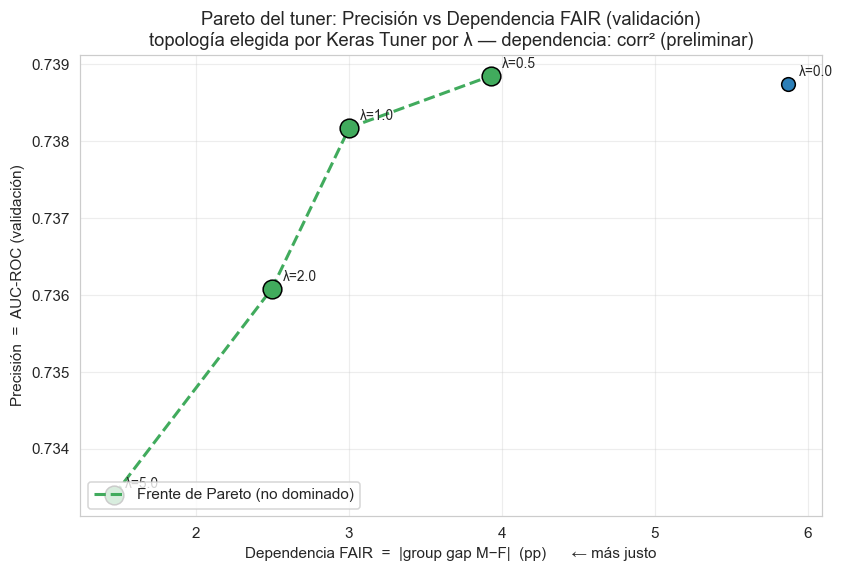

Puntos NO dominados (lambda, AUC_val, gap_pp): [(5.0, 0.7334, 1.46), (2.0, 0.7361, 2.5), (1.0, 0.7382, 3.0), (0.5, 0.7389, 3.93)]

Topologia backbone (mayor AUC, de λ=0.5): {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'lr': 0.006678619769811224, 'units_0': 80, 'units_1': 112, 'units_2': 48, 'tuner/epochs': 15, 'tuner/initial_epoch': 5, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


In [6]:
# === Pareto del tuner: AUC (Y) vs Dependencia FAIR = |group gap| (X) — E2 ===
# CORREGIDO (Tanda 3): TODO en VALIDACION (mismo split, misma arquitectura-familia).
# NO se pinta la estrella base-03 (era de TEST y sin capa custom -> comparacion invalida).
# La dependencia penalizada es corr2 (fallback); el eje X reporta el group gap, ligado
# monotonamente a corr2 bajo s binaria (se aclara en Limitaciones).
import json as _json

if len(registros):
    puntos = [{"lambda": r["lambda"], "auc": r["auc"], "gap_pp": r["gap_pp"]} for r in registros]
    frente = tuning.pareto_front(puntos)
    set_frente = {(round(p["auc"], 6), round(p["gap_pp"], 6)) for p in frente}

    fig, ax = plt.subplots(figsize=(7.8, 5.3))
    for r in registros:
        en_frente = (round(r["auc"], 6), round(r["gap_pp"], 6)) in set_frente
        ax.scatter(abs(r["gap_pp"]), r["auc"], s=150 if en_frente else 80,
                   color=COLOR_ACENTO if en_frente else COLOR_PAGA,
                   edgecolor="black", zorder=3 if en_frente else 2)
        ax.annotate(f"λ={r['lambda']}", (abs(r["gap_pp"]), r["auc"]),
                    textcoords="offset points", xytext=(7, 5), fontsize=9)
    fx = [abs(p["gap_pp"]) for p in frente]; fy = [p["auc"] for p in frente]
    ax.plot(fx, fy, color=COLOR_ACENTO, lw=2, ls="--", zorder=2, label="Frente de Pareto (no dominado)")

    ax.set_xlabel("Dependencia FAIR  =  |group gap M−F|  (pp)      ← más justo")
    ax.set_ylabel("Precisión  =  AUC-ROC (validación)")
    ax.set_title("Pareto del tuner: Precisión vs Dependencia FAIR (validación)\n"
                 "topología elegida por Keras Tuner por λ — dependencia: corr² (preliminar)")
    ax.legend(loc="lower left", frameon=True)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__pareto_auc_vs_gap.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("E2 guardada:", ruta)
    plt.show()

    df_pareto = pd.DataFrame(frente)
    df_pareto.to_csv(TAB_DIR / "06_tuner__pareto_puntos.csv", index=False)
    print("Puntos NO dominados (lambda, AUC_val, gap_pp):",
          [(p["lambda"], round(p["auc"], 4), round(p["gap_pp"], 2)) for p in frente])

    # Topologia BACKBONE para el barrido limpio = la de mayor AUC (mejor capacidad)
    reg_backbone = max(registros, key=lambda r: r["auc"])
    HP_BACKBONE = _json.loads(reg_backbone["hp_values"])
    print(f"\nTopologia backbone (mayor AUC, de λ={reg_backbone['lambda']}): {HP_BACKBONE}")


## Barrido LIMPIO: topología fija + multi-semilla (aísla λ)

> **Por qué esta sección (revisión Tanda 3).** En el barrido del tuner cada λ usa una **topología distinta**, así que las variaciones de AUC/gap mezclan el efecto del *fairness* con el de cambiar de arquitectura — y con **una sola semilla** las diferencias de AUC (~0,001) caen dentro del **ruido de entrenamiento**.
>
> Aquí **fijamos la topología backbone** (la de mayor AUC del tuner) y barremos λ **entrenando varias semillas por valor**. Así: (1) el único factor que cambia es λ → la frontera mide *fairness puro*; (2) reportamos **media ± desviación** (barras de error) → se ve si las diferencias entre λ superan el ruido. Esta es la frontera **rigurosa**; la del tuner queda como evidencia del AutoML.


Backbone fijo: {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'lr': 0.006678619769811224, 'units_0': 80, 'units_1': 112, 'units_2': 48, 'tuner/epochs': 15, 'tuner/initial_epoch': 5, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}
Barriendo lambda=[0.0, 0.5, 1.0, 2.0, 5.0] con 3 semillas [42, 7, 123] (val + test)...



lambda=0.0  val AUC=0.7396±0.0008  gap=+5.74±0.27pp  |  test AUC=0.7407  gap=+5.73pp
lambda=0.5  val AUC=0.7385±0.0006  gap=+3.76±0.04pp  |  test AUC=0.7407  gap=+3.77pp
lambda=1.0  val AUC=0.7369±0.0008  gap=+2.79±0.24pp  |  test AUC=0.7393  gap=+2.81pp
lambda=2.0  val AUC=0.7350±0.0004  gap=+2.27±0.22pp  |  test AUC=0.7374  gap=+2.25pp
lambda=5.0  val AUC=0.7321±0.0012  gap=+1.45±0.26pp  |  test AUC=0.7344  gap=+1.46pp



Figura Pareto limpia guardada: ..\results\figures\06_tuner__pareto_limpia_semillas.png


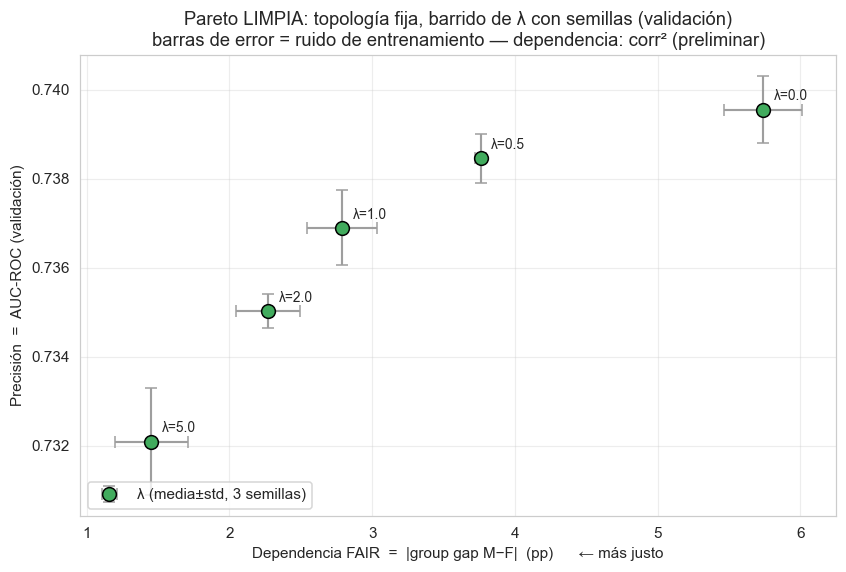

In [7]:
# === Barrido limpio: topologia FIJA (backbone) + semillas, val Y test ===
SEEDS = [42, 7, 123]
if len(registros):
    print(f"Backbone fijo: {HP_BACKBONE}")
    print(f"Barriendo lambda={LAMBDAS} con {len(SEEDS)} semillas {SEEDS} (val + test)...\n")
    filas_limpio = tuning.sweep_lambda_fixed(
        data, LAMBDAS, HP_BACKBONE, seeds=SEEDS,
        n_features=N_FEATURES, include_custom_layer=True, class_weights=CW,
        epochs=40, test=(X_test, y_test, s_test), verbose=0)

    df_limpio = pd.DataFrame(filas_limpio)
    for _, r in df_limpio.iterrows():
        print(f"lambda={r['lambda']:<4} val AUC={r['auc_mean']:.4f}±{r['auc_std']:.4f}  "
              f"gap={r['gap_mean']:+.2f}±{r['gap_std']:.2f}pp  |  "
              f"test AUC={r['auc_test_mean']:.4f}  gap={r['gap_test_mean']:+.2f}pp")
    df_limpio.to_csv(TAB_DIR / "06_tuner__pareto_limpio_seeds.csv", index=False)

    # Figura: Pareto limpia con barras de error (validacion)
    fig, ax = plt.subplots(figsize=(7.8, 5.3))
    ax.errorbar(df_limpio["gap_mean"].abs(), df_limpio["auc_mean"],
                xerr=df_limpio["gap_std"], yerr=df_limpio["auc_std"],
                fmt="o", color=COLOR_ACENTO, ecolor="#9e9e9e", elinewidth=1.4,
                capsize=4, ms=9, mec="black", zorder=3, label=f"λ (media±std, {len(SEEDS)} semillas)")
    for _, r in df_limpio.iterrows():
        ax.annotate(f"λ={r['lambda']}", (abs(r["gap_mean"]), r["auc_mean"]),
                    textcoords="offset points", xytext=(7, 6), fontsize=9)
    ax.set_xlabel("Dependencia FAIR  =  |group gap M−F|  (pp)      ← más justo")
    ax.set_ylabel("Precisión  =  AUC-ROC (validación)")
    ax.set_title("Pareto LIMPIA: topología fija, barrido de λ con semillas (validación)\n"
                 "barras de error = ruido de entrenamiento — dependencia: corr² (preliminar)")
    ax.legend(loc="lower left", frameon=True)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__pareto_limpia_semillas.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("\nFigura Pareto limpia guardada:", ruta)
    plt.show()


## Selección de la mejor topología

Aquí se elegirá la **configuración de compromiso** (necesariamente **con dropout**) que **hereda el notebook 07** para MC-Dropout (cruce **D-3.2 ↔ D-4.1**), persistiendo sus hiperparámetros y el resumen de trials.

In [8]:
# === Seleccion de la topologia de compromiso (la hereda el NB07, D-3.2 <-> D-4.1) ===
# Se decide sobre el barrido LIMPIO (topologia fija + semillas), no sobre el ruidoso
# del tuner: de los lambda cuyo |gap| medio mejora >=30% respecto a lambda=0, el de
# mayor AUC medio. El precio de la justicia se reporta en TEST con media±std.
if len(registros):
    r0 = df_limpio[df_limpio["lambda"] == 0.0].iloc[0]
    gap0 = abs(r0["gap_mean"])
    cand = df_limpio[df_limpio["gap_mean"].abs() <= 0.7 * gap0]
    if len(cand) == 0:
        cand = df_limpio
    fila_star = cand.loc[cand["auc_mean"].idxmax()]
    LAMBDA_STAR = float(fila_star["lambda"])

    print(f"Topologia de compromiso: backbone {HP_BACKBONE}  con  λ*={LAMBDA_STAR}")
    print(f"  val:  AUC={fila_star['auc_mean']:.4f}±{fila_star['auc_std']:.4f}  "
          f"gap={fila_star['gap_mean']:+.2f}±{fila_star['gap_std']:.2f}pp")
    assert float(HP_BACKBONE["dropout_rate"]) > 0, "El backbone DEBE tener dropout (MC-Dropout NB07)"
    print(f"  dropout={HP_BACKBONE['dropout_rate']:.1f} > 0  ->  apto para MC-Dropout del NB07 (D-4.1)")

    # Precio de la justicia en TEST (media±std de las semillas): lambda=0 vs lambda*
    rt0 = df_limpio[df_limpio["lambda"] == 0.0].iloc[0]
    rts = df_limpio[df_limpio["lambda"] == LAMBDA_STAR].iloc[0]
    dAUC = rts["auc_test_mean"] - rt0["auc_test_mean"]
    dgap = abs(rt0["gap_test_mean"]) - abs(rts["gap_test_mean"])
    print("\n=== Precio de la justicia en TEST (media de semillas, topologia fija) ===")
    print(f"  λ=0  : AUC={rt0['auc_test_mean']:.4f}±{rt0['auc_test_std']:.4f}  gap={rt0['gap_test_mean']:+.2f}±{rt0['gap_test_std']:.2f}pp")
    print(f"  λ={LAMBDA_STAR} : AUC={rts['auc_test_mean']:.4f}±{rts['auc_test_std']:.4f}  gap={rts['gap_test_mean']:+.2f}±{rts['gap_test_std']:.2f}pp")
    print(f"  -> ΔAUC={dAUC:+.4f}  |  |gap| reducido en {dgap:+.2f}pp")
    if abs(dAUC) < max(rt0["auc_test_std"], rts["auc_test_std"]):
        print("  (ΔAUC dentro de 1 std -> el sacrificio de precision es indistinguible de cero)")

    # Persistir trials del tuner (completos, con test e hp_values) -> tabla de apoyo
    df_full = pd.DataFrame(registros)
    df_full["es_backbone"] = df_full["lambda"] == reg_backbone["lambda"]
    df_full["estrategia"] = STRATEGY
    df_full.to_csv(TAB_DIR / "06_tuner__trials.csv", index=False)
    print("\nTrials guardados:", TAB_DIR / "06_tuner__trials.csv")


Topologia de compromiso: backbone {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'lr': 0.006678619769811224, 'units_0': 80, 'units_1': 112, 'units_2': 48, 'tuner/epochs': 15, 'tuner/initial_epoch': 5, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}  con  λ*=0.5
  val:  AUC=0.7385±0.0006  gap=+3.76±0.04pp
  dropout=0.3 > 0  ->  apto para MC-Dropout del NB07 (D-4.1)

=== Precio de la justicia en TEST (media de semillas, topologia fija) ===
  λ=0  : AUC=0.7407±0.0006  gap=+5.73±0.28pp
  λ=0.5 : AUC=0.7407±0.0007  gap=+3.77±0.03pp
  -> ΔAUC=+0.0000  |  |gap| reducido en +1.95pp
  (ΔAUC dentro de 1 std -> el sacrificio de precision es indistinguible de cero)

Trials guardados: ..\results\tables\06_tuner__trials.csv


## Curva de loss del mejor trial (E4)

Aquí se graficará el `history` del **mejor trial** para evidenciar convergencia, entregable **E4** (transversal a todos los notebooks que entrenan un modelo final).

Modelo de compromiso (pesos+json) guardado para el NB07 en: ..\data\models


E4 guardada: ..\results\figures\06_tuner__curva_loss_mejor.png


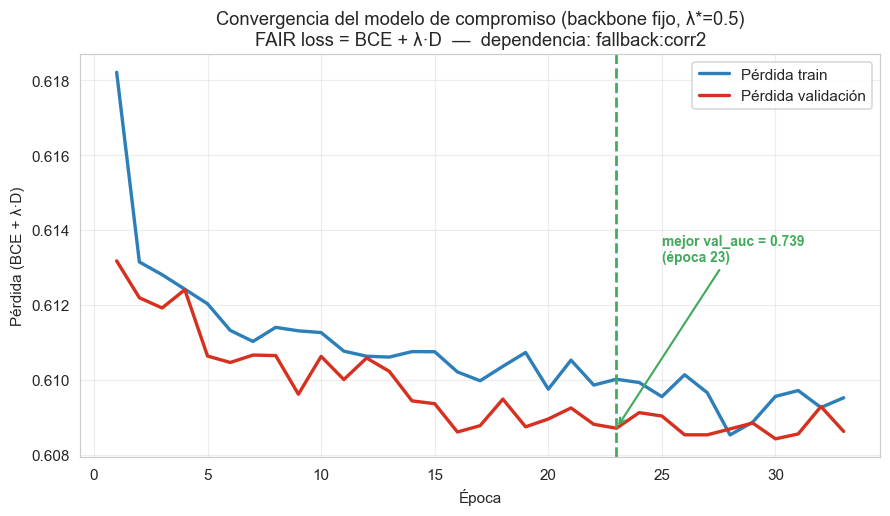

In [9]:
# === Curva de loss del modelo de compromiso real (backbone + λ*) — E4 ===
# Se reentrena UNA vez el modelo que hereda el NB07 (backbone fijo con λ*) para
# mostrar su convergencia, y se persiste para la Tarea 4 (MC-Dropout).
if len(registros):
    import json as _json2
    keras.utils.set_random_seed(RNG)
    Xtr_np = X_train.to_numpy("float32"); ytr_pk = tuning.pack_ys(y_train, s_train)
    Xvl_np = X_val.to_numpy("float32");   yvl_pk = tuning.pack_ys(y_val, s_val)

    modelo_compromiso = tuning.build_fixed_model(HP_BACKBONE, LAMBDA_STAR,
                                                 n_features=N_FEATURES,
                                                 include_custom_layer=True, class_weights=CW)
    stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                         patience=10, restore_best_weights=True)
    hist_star = modelo_compromiso.fit(Xtr_np, ytr_pk, validation_data=(Xvl_np, yvl_pk),
                                      epochs=60, batch_size=512, callbacks=[stop], verbose=0)

    # Persistir para que el NB07 lo herede (MC-Dropout, D-4.1): pesos + json de hp.
    # No se usa save() .keras porque la FAIR loss es un closure no serializable; el
    # NB07 reconstruye el backbone con tuning.build_fixed_model(HP) y carga los pesos.
    ruta_modelo = PROC_DIR.parent / "models"; ruta_modelo.mkdir(parents=True, exist_ok=True)
    modelo_compromiso.save_weights(ruta_modelo / "06_modelo_compromiso.weights.h5")
    (ruta_modelo / "06_modelo_compromiso.json").write_text(_json2.dumps({
        "hp_backbone": HP_BACKBONE, "lambda_star": LAMBDA_STAR,
        "class_weights": list(CW), "n_features": int(N_FEATURES),
        "include_custom_layer": True, "fair_source": tuning.fair_loss_source(),
    }, indent=2), encoding="utf-8")
    print("Modelo de compromiso (pesos+json) guardado para el NB07 en:", ruta_modelo)

    h = hist_star.history
    epocas = np.arange(1, len(h["loss"]) + 1)
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.plot(epocas, h["loss"], color=COLOR_PAGA, lw=2.2, label="Pérdida train")
    ax.plot(epocas, h["val_loss"], color=COLOR_IMPAGA, lw=2.2, label="Pérdida validación")
    if "val_auc" in h:
        best = int(np.argmax(h["val_auc"]))
        ax.axvline(best + 1, color=COLOR_ACENTO, ls="--", lw=1.8)
        ax.annotate(f"mejor val_auc = {max(h['val_auc']):.3f}\n(época {best + 1})",
                    xy=(best + 1, h["val_loss"][best]),
                    xytext=(best + 3, max(h["val_loss"])),
                    color=COLOR_ACENTO, fontsize=9, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=COLOR_ACENTO, lw=1.4))
    ax.set_title(f"Convergencia del modelo de compromiso (backbone fijo, λ*={LAMBDA_STAR})\n"
                 f"FAIR loss = BCE + λ·D  —  dependencia: {tuning.fair_loss_source()}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida (BCE + λ·D)")
    ax.legend(loc="upper right", frameon=True)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()
    ruta = FIG_DIR / "06_tuner__curva_loss_mejor.png"
    fig.savefig(ruta, bbox_inches="tight", dpi=150)
    print("E4 guardada:", ruta)
    plt.show()


## Limitaciones y honestidad metodológica

Recogido de la auto-revisión (revisor de código + "profesor" + crítico). Lo que **sí** está controlado y lo que queda como **limitación declarada**:

**Controlado**
- **Sin fuga de género:** `CODE_GENDER` nunca entra en `X` (`assert`); solo viaja en `y_true=[y,s]` y en la auditoría del gap (D-2.5).
- **Test reservado:** la topología y `λ*` se eligen en **validación**; el test solo se usa para el reporte final (D-P.6).
- **Pareto en un solo conjunto:** la figura del tuner es **toda de validación** (antes mezclaba un punto de test del base-03 → corregido).
- **Ruido acotado:** el barrido **limpio** fija la topología y promedia **3 semillas** con barras de error → se distingue señal de ruido. El criterio de compromiso avisa si `ΔAUC` cae dentro de 1σ.
- **Reproducible:** `06_tuner__trials.csv` guarda `hp_values` completos (todas las `units_i`), no solo `units_0`.

**Limitaciones declaradas**
- **Dependencia = corr² (preliminar), no la HSIC de D-2.1.** El compañero aún no ha entregado `src/fair_loss.py`; el diseño es **enchufable** (cuando llegue la HSIC, `fair_source` pasará de `fallback:corr2` a `src.fair_loss` sin tocar el notebook). corr² capta dependencia lineal/de medias; la HSIC captaría no-linealidades y **podría mover la frontera**. Por eso las figuras se marcan *preliminar*.
- **corr² ≈ monótona del group gap** bajo `s` binaria: se **penaliza** corr² y se **reporta** group gap (ligados, no idénticos). Reducir el gap subiendo λ es en parte *esperado por construcción*; el valor está en **cuánto cuesta en AUC**, no en que baje el gap.
- **Group gap = paridad demográfica** (diferencia de probabilidad media), no equalized-odds. D-2.3 lo fija como métrica principal, pero no condiciona por `y`; una auditoría completa añadiría ΔTPR/ΔFPR por grupo.
- **Búsqueda sobre submuestra de 60k** (retrain en train completo) y presupuesto modesto (`max_trials=8`, `max_epochs=15`): el tuner **confirma** una buena topología más que descubrir una exótica; con tan poca capacidad el factor dominante de la frontera es λ, no la arquitectura.
- **Empate de estrategias (D-3.1):** Hyperband ≈ RandomSearch dentro del ruido; se usa Hyperband por la propuesta por defecto, no por superioridad medida.


## Entregables y dependencias

Este notebook produce:

- **E2** · Pareto **AUC vs group gap** → figura `results/figures/06_tuner__pareto_auc_vs_gap.png` + tabla `results/tables/06_tuner__pareto_puntos.csv`.
- **Trials** del tuner → `results/tables/06_tuner__trials.csv` (con la topología de compromiso elegida).
- **E4** · Curva de loss del mejor trial → `results/figures/06_tuner__curva_loss_mejor.png`.
- *(Presentación)* **análisis de la Pareto**: lectura del compromiso precisión ↔ dependencia FAIR.

**Dependencias.** Aguas arriba: **03** (baseline de precisión), **04** (capa custom) y **05** (FAIR loss `BCE + λ·D`), que el `build_model(hp)` integra. Aguas abajo: **07** **hereda la topología + dropout** que aquí se fija para MC-Dropout — el **cruce D-3.2 ↔ D-4.1** que obliga a meter el dropout en el espacio de búsqueda sí o sí.